### Student Information
Name: 謝閔如

Student ID: u56134017

GitHub ID: Avery9990

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [3]:
# 導入必要的函式庫
import pandas as pd
import numpy as np
import nltk
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取Reddit
df = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')

# 檢視資料集
print(df)
print(df.shape)
print(df.head())
print(df.info())

# 檢查缺失值
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 標籤分布
print(df['label'].value_counts())

        type             datetime  post_id         subreddit  \
0    comment  2025-04-11 17:29:56  mmli62w    wallstreetbets   
1    comment   2025-04-12 1:12:19  mmnu7v9    wallstreetbets   
2    comment  2025-04-10 15:09:41  mmeevio       StockMarket   
3       post  2023-08-30 17:12:55  165kllm  stockstobuytoday   
4    comment  2025-04-11 14:48:05  mmkl6bw       StockMarket   
..       ...                  ...      ...               ...   
842  comment   2021-06-30 4:06:06  h3iv6pq  stockstobuytoday   
843  comment   2025-04-11 5:01:24  mmijiuz       StockMarket   
844     post  2025-03-24 12:30:39  1jipi4v  stockstobuytoday   
845  comment  2025-04-11 20:13:26  mmmely7    wallstreetbets   
846  comment   2025-04-12 3:09:06  mmobyz1    wallstreetbets   

                                                 title                author  \
0      Retardation is on the menu boys! WSB is so back          StickyTip420   
1    Retail giant TARGET has now declined for 10 co...  Comfortable-Dog

subreddit
stocks              274
StockMarket         250
stockstobuytoday    174
wallstreetbets      149
Name: count, dtype: int64


<Axes: title={'center': 'Category distribution'}, xlabel='subreddit'>

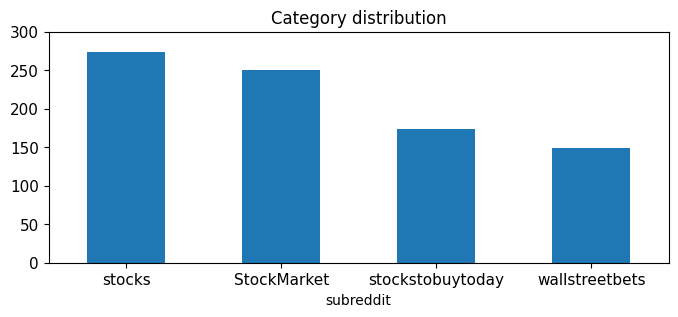

In [ ]:
#subreddit以長條圖呈現
print(df.subreddit.value_counts())

df.subreddit.value_counts().plot(kind = 'bar',
                                    title = 'Category distribution',
                                    ylim = [0, 300],rot = 0, fontsize = 11, figsize = (8,3))

                  Data_Frame_1  Data_Frame_2
subreddit                                   
stocks                     154           274
StockMarket                149           250
stockstobuytoday           105           174
wallstreetbets              92           149


<Axes: title={'center': 'Category distribution'}, xlabel='subreddit'>

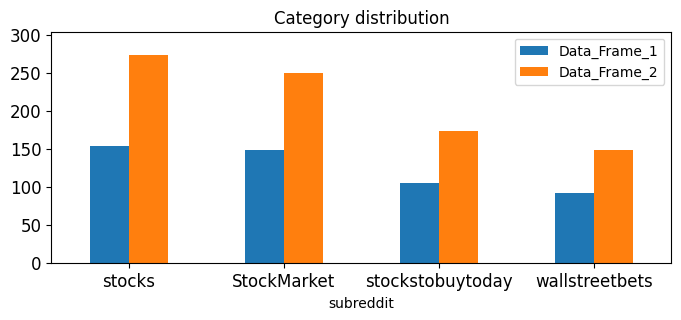

In [ ]:
# 抽樣500筆數據進行比較
df_sample = df.sample(n=500)

dat_1 = df_sample.subreddit.value_counts()
dat_2 = df.subreddit.value_counts()
dat_combined = pd.DataFrame({
    'Data_Frame_1': dat_1,
    'Data_Frame_2': dat_2})
print(dat_combined)
dat_combined.plot(kind = 'bar',title = 'Category distribution',
                  ylim = [0, dat_combined.max().max()+30], 
                  rot = 0, fontsize = 12, figsize = (8,3))

In [13]:
# 文字轉向量
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
df_counts = count_vect.fit_transform(df.entities) 
print(df_counts)

  (np.int32(1), np.int32(1829))	1
  (np.int32(1), np.int32(408))	1
  (np.int32(1), np.int32(514))	1
  (np.int32(1), np.int32(1450))	1
  (np.int32(2), np.int32(1925))	1
  (np.int32(3), np.int32(2073))	1
  (np.int32(3), np.int32(1742))	1
  (np.int32(3), np.int32(1493))	3
  (np.int32(3), np.int32(738))	1
  (np.int32(3), np.int32(1214))	2
  (np.int32(3), np.int32(1199))	1
  (np.int32(3), np.int32(1865))	2
  (np.int32(3), np.int32(2048))	2
  (np.int32(3), np.int32(1893))	1
  (np.int32(3), np.int32(999))	2
  (np.int32(3), np.int32(2072))	2
  (np.int32(3), np.int32(1577))	1
  (np.int32(3), np.int32(1953))	1
  (np.int32(3), np.int32(1412))	1
  (np.int32(3), np.int32(1709))	1
  (np.int32(3), np.int32(1366))	2
  (np.int32(3), np.int32(389))	1
  (np.int32(3), np.int32(1018))	1
  (np.int32(3), np.int32(1655))	1
  (np.int32(3), np.int32(1471))	1
  :	:
  (np.int32(836), np.int32(1435))	1
  (np.int32(836), np.int32(811))	1
  (np.int32(836), np.int32(1372))	2
  (np.int32(837), np.int32(1852))	1
  (np.

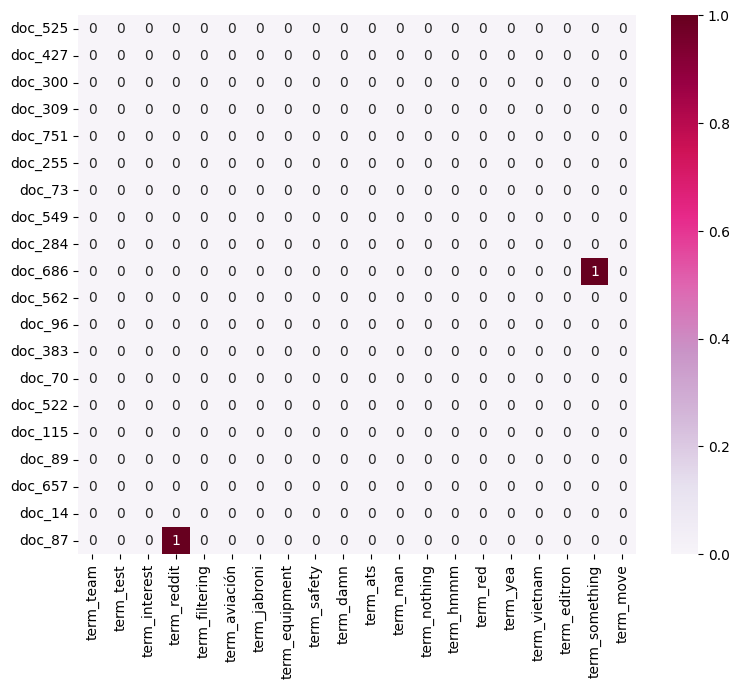

In [17]:
import random
all_terms = list(range(df_counts.shape[1]))
all_docs_idx = list(range(df_counts.shape[0]))

# 隨機抽20個term index與document index
picked_terms = random.sample(all_terms, 20)
picked_docs_idx = random.sample(all_docs_idx, 20)

#存成名稱
terms = count_vect.get_feature_names_out()
picked_terms_1 = [terms[i] for i in picked_terms]
plot_x_rdm = ["term_" + str(i) for i in picked_terms_1]

plot_y_rdm = ["doc_" + str(i) for i in picked_docs_idx]

plot_z_rdm = df_counts[picked_docs_idx, :][:, picked_terms].toarray()

# 建立DataFrame
df_todraw = pd.DataFrame(plot_z_rdm, columns=plot_x_rdm, index=plot_y_rdm)

# Plot
plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_todraw,
                 cmap="PuRd",
                 vmin=0, vmax=1, annot=True)
plt.show()


C:\Users\hsieh\AppData\Local\Temp\ipykernel_17292\3599406256.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);


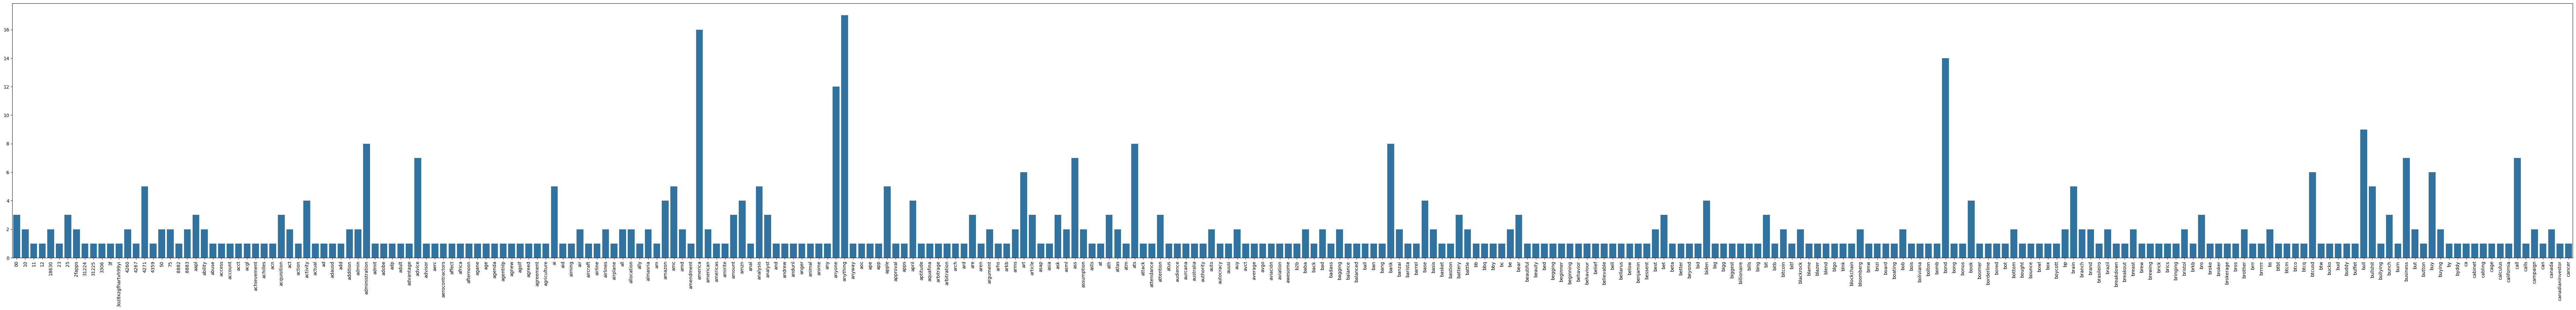

In [20]:
term_frequencies = []
for j in range(0,df_counts.shape[1]):
    term_frequencies.append(sum(df_counts[:,j].toarray()))

term_frequencies = np.asarray(df_counts.sum(axis=0))[0]
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect.get_feature_names_out()[:300], 
            y=term_frequencies[:300])
g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);

# Phase 2

In [ ]:
### Begin Assignment Here